In [29]:
# Synthetic Coffee Shop Customer & Transaction Generator
# Author: Kier Zarate
# Date: October 2, 2026
!pip install Faker

In [30]:
# imports
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from faker import Faker
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')


# Creating the Initial Customer Orders

In [31]:
# creating coffee shop orders synthetic dataset
fake = Faker()
Faker.seed(42)
np.random.seed(42)

end_date = datetime(2026, 1, 1)
start_date = end_date - timedelta(days=4 * 365)

# generate customers
n_customers = 5200
customer_ids = np.array([fake.uuid4()[:8] for _ in range(n_customers)]) # create random customer id
ages = np.clip((np.random.gamma(shape=3, scale=8, size=n_customers) + 18).astype(int), 18, 70) # generate ages from 18 to 70
experience_factor = np.log1p(np.maximum(0, ages - 18)) # creating experience factor as basis for a customers income
base_income = 9500 + (experience_factor * 5500) # income is based on the age of a customer
income_noise = np.random.lognormal(mean=0, sigma=0.4, size=n_customers) # since not every age and income is linear, we apply noise
incomes = np.round(base_income * income_noise, -2) # applies noise into customers income, -2 rounding off to the nearest hundred
genders = np.random.choice(['Male', 'Female'], size=n_customers, p=[0.2, 0.8]) # create random gender 20% male and 80% female

customer_df = pd.DataFrame(
    {"customer_id": customer_ids, "age": ages, "income": incomes, 'gender' : genders}
)

# generate orders
date_range = pd.date_range(start=start_date, end=end_date, freq="D") # gets all the dates from start to end
num_days = len(date_range) # number of days from start to end

daily_average = np.random.randint(20, 50, size=num_days) # set the limits of daily average to 20 orders to 50 orders
daily_orders = np.random.poisson(lam=daily_average, size=num_days) # creates daily orders with randomized noise


# add holiday fluctuations
holidays = [
    {'month' : 2, 'day': 14, 'year': 2022, 'count' : np.random.randint(60,200)}, # valentines day
    {'month' : 2, 'day': 14, 'year': 2023, 'count' : np.random.randint(60,200)},
    {'month' : 2, 'day': 14, 'year': 2024, 'count' : np.random.randint(60,200)},
    {'month' : 2, 'day': 14, 'year': 2025, 'count' : np.random.randint(60,200)},
    {'month' : 12, 'day' : 23, 'year': 2022, 'count' : np.random.randint(40,80)}, # christmas
    {'month' : 12, 'day' : 23, 'year': 2023, 'count' : np.random.randint(40,80)},
    {'month' : 12, 'day' : 23, 'year': 2024, 'count' : np.random.randint(40,80)},
    {'month' : 12, 'day' : 23, 'year': 2025, 'count' : np.random.randint(40,80)},
    {'month' : 5, 'day' : 8, 'year': 2022, 'count': np.random.randint(50,200)},# mothers day
    {'month' : 5, 'day' : 14, 'year': 2023, 'count': np.random.randint(50,200)},
    {'month' : 5, 'day' : 12, 'year': 2024, 'count': np.random.randint(50,200)},
    {'month' : 5, 'day' : 11, 'year': 2025, 'count': np.random.randint(50,200)},
    {'month' : 6, 'day' : 19, 'year': 2022, 'count': np.random.randint(70,100)},# fathers day
    {'month' : 6, 'day' : 18, 'year': 2023, 'count': np.random.randint(70,100)},
    {'month' : 6, 'day' : 16, 'year': 2024, 'count': np.random.randint(70,100)},
    {'month' : 6, 'day' : 15, 'year': 2025, 'count': np.random.randint(70,100)},
    {'month' : 11, 'day' : 1, 'year': 2022, 'count': np.random.randint(70,100)}, # all souls day
    {'month' : 11, 'day' : 1, 'year': 2023, 'count': np.random.randint(70,100)},
    {'month' : 11, 'day' : 1, 'year': 2024, 'count': np.random.randint(70,100)},
    {'month' : 11, 'day' : 1, 'year': 2025, 'count': np.random.randint(70,100)},

]

for h in holidays:
  holiday_mask = (date_range.month == h['month']) & (date_range.day == h['day']) & (date_range.year == h['year'])
  daily_orders = np.where(holiday_mask,h['count'], daily_orders) # changes the order count for specific holidays

total_orders = np.sum(daily_orders) # sum of all orders
order_dates = np.repeat(date_range, daily_orders) # Repeat each date according to how many orders happened on that day

# hour probability of orders
hour_probabilities = [
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00,  # 12am to 5:59am
    0.00, 0.00, 0.00, 0.00, 0.00, 0.02,  # 6am to 11:59 am
    0.04, 0.03, 0.02, 0.04, 0.05, 0.08,  # 12 pm  to 5:59pm
    0.09, 0.08, 0.05, 0.00, 0.00, 0.00,  # 6pm to 11:59 pm
]
# sum of probabilities should be equal to 1 in order to be used in np.random.choice
hour_probabilities = np.array(hour_probabilities) / np.sum(hour_probabilities)

hours = np.random.choice(24, size=total_orders, p=hour_probabilities)
minutes = np.random.randint(0, 60, size=total_orders)
seconds = np.random.randint(0, 60, size=total_orders)

# combines order_dates, hours, minutes and seconds
order_timestamps = (
    order_dates
    + pd.to_timedelta(hours, unit="h")
    + pd.to_timedelta(minutes, unit="m")
    + pd.to_timedelta(seconds, unit="s")
)

# creates randomized probability for each customers order
# increasing the shape changes the distribution into normal, mean = shape * scale.
# increasing the scale makes the values larger.
# without this, customer orders will not be random
customer_weights = np.random.gamma(shape=0.6, scale=1.0, size=n_customers)

# sum the probabilities to 1
customer_probabilities = customer_weights / np.sum(customer_weights)

# sample customer id's based on the randomized probability
sampled_customer_ids = np.random.choice(
    customer_df['customer_id'],
    size=total_orders,
    replace=True,
    p=customer_probabilities
)

# map the sampled customer ids back to their respective attributes (age, income)
sampled_customers = pd.DataFrame({'customer_id': sampled_customer_ids}).merge(
    customer_df, on='customer_id', how='left'
)

# create random payment method based on probabilities
payment_method = np.random.choice(['Cash', 'Card', 'Online'], size=total_orders, p=[0.7, 0.2, 0.1])
order_ids = [f"ORD-{fake.unique.numerify('#####@')}" for _ in range(total_orders)] # create random order id

df = pd.DataFrame(
    {
        "order_id": order_ids,
        "order_date": pd.to_datetime(order_timestamps),
        "customer_id": sampled_customers['customer_id'],
        "age": sampled_customers["age"],
        "gender" : sampled_customers['gender'],
        "income": sampled_customers["income"],
        "payment_method" : payment_method
    }
)

df

,order_id,order_date,customer_id,age,gender,income,payment_method
0,ORD-17674,2022-01-02 19:45:31,3737cc38,56,Female,20500.0,Cash
1,ORD-24151,2022-01-02 17:32:03,b8db0672,40,Female,49600.0,Cash
2,ORD-152858,2022-01-02 13:58:33,e1d5c0dc,65,Female,50400.0,Cash
3,ORD-81506,2022-01-02 18:21:00,6fdc0bad,23,Female,14800.0,Cash
4,ORD-85380,2022-01-02 19:59:20,e43081aa,31,Female,39100.0,Online
...,...,...,...,...,...,...,...
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash
51994,ORD-75267,2026-01-01 18:40:56,011bb348,39,Female,23800.0,Online
51995,ORD-46762,2026-01-01 18:02:13,c249f59a,39,Male,31100.0,Cash
51996,ORD-588807,2026-01-01 19:38:17,bada0c94,46,Female,26000.0,Card


In [32]:
# since random number of orders are divided into each , the total customer can't be exactly the same number we set n_customers
df['customer_id'].nunique()

4287

In [33]:
# distribution of each customers order
df.groupby(['customer_id']).size().reset_index(name='orders').sort_values('orders').describe()

,orders
count,4287.000000
mean,12.129228
std,13.702121
min,1.000000
25%,3.000000
50%,7.000000
75%,16.000000
max,122.000000


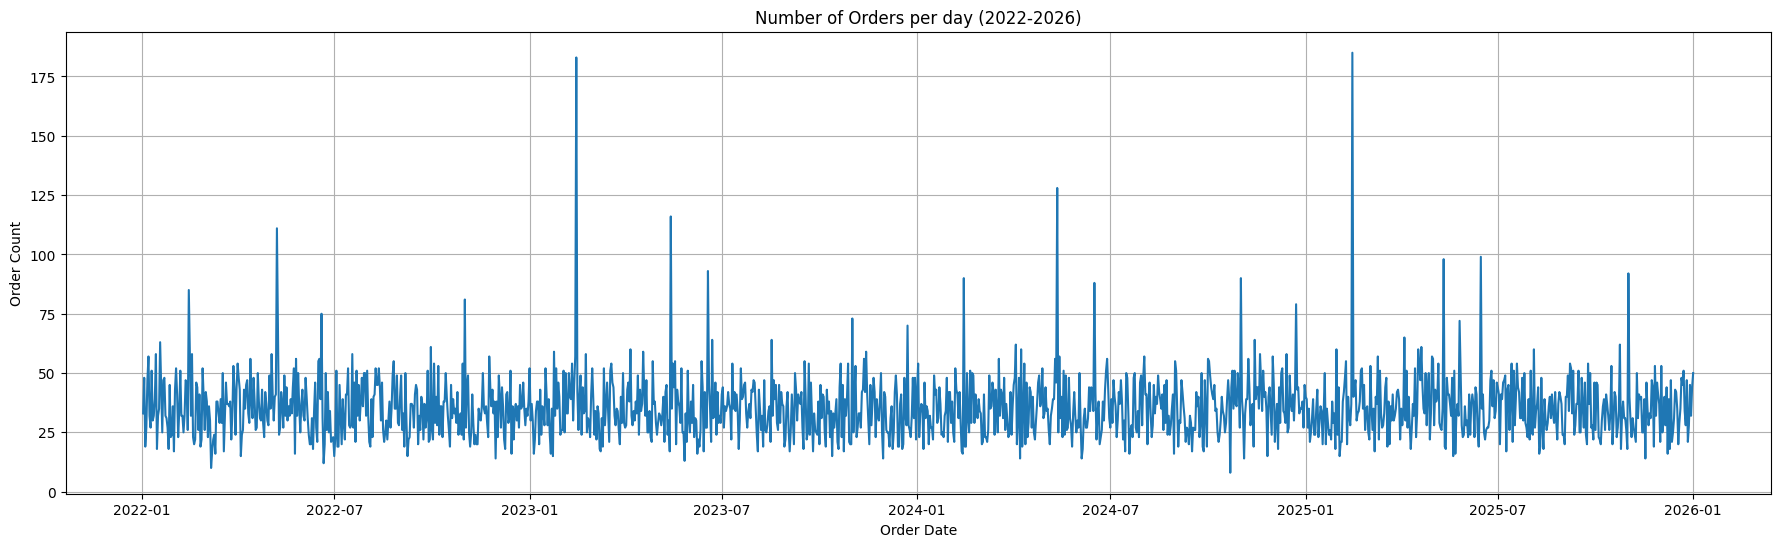

In [34]:
# daily orders
# by using poisson distribution, random fluctuations is simulated
ax = df.groupby(df['order_date'].dt.date).size().plot(figsize=(19,6), x_compat=True)
plt.grid(True)
plt.title('Number of Orders per day (2022-2026)')
plt.xlabel('Order Date')
plt.ylabel('Order Count')
plt.show()

# Creating Random Customer Order Items

In [35]:
# creating menu for order items
menu = {'Americano' : 100,
 'Cafe Latte' : 120,
 'Spanish Latte' : 140,
 "Barista's Drink" : 155,
 'Caramel Macchaiatto' : 160,
 'Matcha Latte' : 180,
 'Choco Latte' : 160,
 'Strawberry Slushie' : 195,
 'Java Chip' : 225,
 'Spare Ribs' : 350,
 'Kare-Kare': 375,
 'Sinigang' : 290,
 'Caldereta': 345,
 'Lechon Kawali' : 289,
 'Chicken Inasal': 310,
 'Burger Steak' : 320,
 'Spaghetti Bolognese' : 215,
 'Carbonara': 280,
 'Greek Salad' : 260,
 'Fried Chicken': 325,
 'Fries' : 100,
 'Overload Pizza' : 420,
 'Cheese Pizza': 390,
 'Hawaiian Pizza': 410,
 'Cake Slice': 125,
 'Cookies': 95}

keys = []
for i, key in enumerate(menu):
  keys.append(key)
print(*keys, sep=',\n')

Americano,
Cafe Latte,
Spanish Latte,
Barista's Drink,
Caramel Macchaiatto,
Matcha Latte,
Choco Latte,
Strawberry Slushie,
Java Chip,
Spare Ribs,
Kare-Kare,
Sinigang,
Caldereta,
Lechon Kawali,
Chicken Inasal,
Burger Steak,
Spaghetti Bolognese,
Carbonara,
Greek Salad,
Fried Chicken,
Fries,
Overload Pizza,
Cheese Pizza,
Hawaiian Pizza,
Cake Slice,
Cookies


In [36]:
# create time and age probabilities for each menu item
p_morning_young = [
    0.02, 0.04, 0.09, 0.05, 0.06, 0.09, 0.03,
    0.05, 0.07, 0.1, 0.06, 0.06, 0.02, 0.07,
    0.07, 0.08, 0.04, 0.04, 0.03, 0.08, 0.08,
    0.03, 0.02, 0.02, 0.08, 0.04]
p_afternoon_young = [
    0.02, 0.04, 0.09, 0.04, 0.075, 0.09, 0.02,
    0.09, 0.08, 0.1, 0.07, 0.1, 0.04, 0.08,
    0.07, 0.09, 0.04, 0.05, 0.04, 0.09, 0.09,
    0.04, 0.03, 0.02, 0.05, 0.02]
p_evening_young = [
    0.001, 0.02, 0.08, 0.03, 0.06, 0.07, 0.03,
    0.08, 0.07, 0.09, 0.05, 0.02, 0.03, 0.06,
    0.07, 0.08, 0.1, 0.1, 0.02, 0.08, 0.08,
    0.05, 0.05, 0.03, 0.06, 0.02]

p_morning_middle = [
    0.06, 0.06, 0.06, 0.04, 0.05, 0.05, 0.04,
    0.03, 0.06, 0.15, 0.07, 0.07, 0.04, 0.07,
    0.07, 0.04, 0.03, 0.03, 0.05, 0.07, 0.04,
    0.02, 0.02, 0.01, 0.09, 0.03]
p_afternoon_middle = [
    0.05, 0.05, 0.09, 0.05, 0.07, 0.07, 0.03,
    0.085, 0.09, 0.1, 0.08, 0.1, 0.06, 0.08,
    0.08, 0.05, 0.035, 0.035, 0.07, 0.08, 0.06,
    0.04, 0.03, 0.02, 0.06, 0.01]
p_evening_middle = [
    0.04, 0.06, 0.08, 0.03, 0.05, 0.05, 0.04,
    0.04, 0.05, 0.09, 0.06, 0.025, 0.02, 0.06,
    0.05, 0.04, 0.15, 0.2, 0.05, 0.08, 0.05,
    0.06, 0.06, 0.03, 0.06, 0.01]

p_morning_older = [
    0.07, 0.065, 0.04, 0.02, 0.02, 0.02, 0.05,
    0.02, 0.03, 0.2, 0.08, 0.05, 0.08, 0.07,
    0.06, 0.02, 0.02, 0.01, 0.09, 0.04, 0.02,
    0.01, 0.01, 0.01, 0.08, 0.01]
p_afternoon_older = [
    0.07, 0.07, 0.035, 0.02, 0.015, 0.025, 0.045,
    0.03, 0.04, 0.15, 0.08, 0.04, 0.07, 0.09,
    0.05, 0.03, 0.02, 0.02, 0.095, 0.04, 0.01,
    0.03, 0.03, 0.02, 0.09, 0.02]
p_evening_older = [
    0.04, 0.05, 0.01, 0.01, 0.01, 0.01, 0.055,
    0.02, 0.02, 0.09, 0.04, 0.015, 0.06, 0.07,
    0.02, 0.02, 0.15, 0.1, 0.07, 0.03, 0.02,
    0.02, 0.02, 0.015, 0.08, 0.001]

# sum of the probabilities should be 1
p_morning_young = np.array(p_morning_young) / np.sum(p_morning_young)
p_afternoon_young = np.array(p_afternoon_young) / np.sum(p_afternoon_young)
p_evening_young = np.array(p_evening_young) / np.sum(p_evening_young)

p_morning_middle = np.array(p_morning_middle) / np.sum(p_morning_middle)
p_afternoon_middle = np.array(p_afternoon_middle) / np.sum(p_afternoon_middle)
p_evening_middle = np.array(p_evening_middle) / np.sum(p_evening_middle)

p_morning_older = np.array(p_morning_older) / np.sum(p_morning_older)
p_afternoon_older = np.array(p_afternoon_older) / np.sum(p_afternoon_older)
p_evening_older = np.array(p_evening_older) / np.sum(p_evening_older)


# map the probability variables based on (time, age group)
prob_dict = {
    ('morning', 'young'): p_morning_young,
    ('afternoon', 'young'): p_afternoon_young,
    ('evening', 'young'): p_evening_young,

    ('morning', 'middle'): p_morning_middle,
    ('afternoon', 'middle'): p_afternoon_middle,
    ('evening', 'middle'): p_evening_middle,

    ('morning', 'older'): p_morning_older,
    ('afternoon', 'older'): p_afternoon_older,
    ('evening', 'older'): p_evening_older,
}

In [37]:
# bin customers by its part of day order and age group
df['part_of_day'] = pd.cut(pd.to_datetime(df['order_date']).dt.hour, bins=[-np.inf,11,17,np.inf], labels=['morning', 'afternoon', 'evening'])
df['age_group'] = pd.cut(df['age'], bins=[17,25,45,np.inf], labels=['young', 'middle','older'])
df.head()

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group
0,ORD-17674,2022-01-02 19:45:31,3737cc38,56,Female,20500.0,Cash,evening,older
1,ORD-24151,2022-01-02 17:32:03,b8db0672,40,Female,49600.0,Cash,afternoon,middle
2,ORD-152858,2022-01-02 13:58:33,e1d5c0dc,65,Female,50400.0,Cash,afternoon,older
3,ORD-81506,2022-01-02 18:21:00,6fdc0bad,23,Female,14800.0,Cash,evening,young
4,ORD-85380,2022-01-02 19:59:20,e43081aa,31,Female,39100.0,Online,evening,middle


In [38]:
# create function that assigns random orders based on TIME and AGE of a customer
def assign_random_orders(df, menu, prob_dict):

    menu_keys = list(menu.keys())

    for (part_of_day, age_group), p_values in prob_dict.items():
        # Create a boolean mask for the current combination
        mask = (df['part_of_day'] == part_of_day) & (df['age_group'] == age_group)
        size = mask.sum()

        # Only assign if matching rows exist
        if size > 0:
            df.loc[mask, 'order'] = np.random.choice(
                menu_keys,
                size=size,
                p=p_values
            )

    return df

In [39]:
# assign random orders in the main dataframe
df = assign_random_orders(df, menu, prob_dict)

In [40]:
# copies the price of the order
df['Price'] = df['order'].replace(menu)

In [41]:
# create category for orders
order_category = {
    "Meal" : ['Spare Ribs','Kare-Kare','Sinigang','Caldereta','Lechon Kawali',
              'Chicken Inasal','Burger Steak','Spaghetti Bolognese','Carbonara','Greek Salad',
              'Fried Chicken','Fries','Overload Pizza','Cheese Pizza','Hawaiian Pizza',],
    "Drinks" : ['Americano','Cafe Latte','Spanish Latte',"Barista's Drink",'Caramel Macchaiatto',
                'Matcha Latte','Choco Latte','Strawberry Slushie','Java Chip',],
    "Dessert" : ['Cake Slice', 'Cookies']
}

# creates dictionary with the order as the key and category as the item
item_to_category = {
    item: category
    for category, items in order_category.items()
    for item in items
}
# maps the item and category
df['order_category'] = df['order'].map(item_to_category)

# Creating Random Multiple Customer Orders

In [42]:
# create random duplicates of the initial orders
duplicated_dfs = df.loc[df.index.repeat(np.random.gamma(shape=1.5, scale=1.5, size=df.shape[0]))] # use gamma to simulate skewness of multiple orders
duplicated_dfs

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group,order,Price,order_category
0,ORD-17674,2022-01-02 19:45:31,3737cc38,56,Female,20500.0,Cash,evening,older,Choco Latte,160,Drinks
1,ORD-24151,2022-01-02 17:32:03,b8db0672,40,Female,49600.0,Cash,afternoon,middle,Lechon Kawali,289,Meal
2,ORD-152858,2022-01-02 13:58:33,e1d5c0dc,65,Female,50400.0,Cash,afternoon,older,Spare Ribs,350,Meal
3,ORD-81506,2022-01-02 18:21:00,6fdc0bad,23,Female,14800.0,Cash,evening,young,Fried Chicken,325,Meal
4,ORD-85380,2022-01-02 19:59:20,e43081aa,31,Female,39100.0,Online,evening,middle,Cheese Pizza,390,Meal
...,...,...,...,...,...,...,...,...,...,...,...,...
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal
51995,ORD-46762,2026-01-01 18:02:13,c249f59a,39,Male,31100.0,Cash,evening,middle,Fries,100,Meal


In [43]:
# separate the duplicated values from the original
duplicates = duplicated_dfs[duplicated_dfs.duplicated(keep='first')] # keep='first' gets the duplicated values
duplicates

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group,order,Price,order_category
6,ORD-472725,2022-01-02 19:37:45,e0827f76,39,Female,51900.0,Cash,evening,middle,Sinigang,290,Meal
9,ORD-206494,2022-01-02 19:37:21,096b7724,30,Female,17000.0,Cash,evening,middle,Lechon Kawali,289,Meal
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Cheese Pizza,390,Meal
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Cheese Pizza,390,Meal
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Cheese Pizza,390,Meal
...,...,...,...,...,...,...,...,...,...,...,...,...
51987,ORD-07102,2026-01-01 18:34:11,9191b363,58,Male,33200.0,Cash,evening,older,Spare Ribs,350,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Kare-Kare,375,Meal


In [44]:
# assign random orders in the duplicates dataframe
duplicates = assign_random_orders(duplicates, menu, prob_dict)

# set the proper price and category for the random orders
duplicates['Price'] = duplicates['order'].replace(menu)
duplicates['order_category'] = duplicates['order'].map(item_to_category)
duplicates

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group,order,Price,order_category
6,ORD-472725,2022-01-02 19:37:45,e0827f76,39,Female,51900.0,Cash,evening,middle,Carbonara,280,Meal
9,ORD-206494,2022-01-02 19:37:21,096b7724,30,Female,17000.0,Cash,evening,middle,Java Chip,225,Drinks
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Strawberry Slushie,195,Drinks
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Chicken Inasal,310,Meal
10,ORD-57824,2022-01-02 16:51:13,37f5c238,43,Female,33300.0,Cash,afternoon,middle,Lechon Kawali,289,Meal
...,...,...,...,...,...,...,...,...,...,...,...,...
51987,ORD-07102,2026-01-01 18:34:11,9191b363,58,Male,33200.0,Cash,evening,older,Cafe Latte,120,Drinks
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Carbonara,280,Meal
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Cafe Latte,120,Drinks
51993,ORD-650036,2026-01-01 18:00:39,cd840a47,51,Female,21900.0,Cash,evening,older,Matcha Latte,180,Drinks


In [45]:
# merge the original and the duplicates
merged = pd.merge(df, duplicates, how='outer')

In [46]:
merged

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group,order,Price,order_category
0,ORD-000004,2025-03-10 12:20:23,ef15b821,63,Female,31600.0,Card,afternoon,older,Americano,100,Drinks
1,ORD-000004,2025-03-10 12:20:23,ef15b821,63,Female,31600.0,Card,afternoon,older,Chicken Inasal,310,Meal
2,ORD-000004,2025-03-10 12:20:23,ef15b821,63,Female,31600.0,Card,afternoon,older,Kare-Kare,375,Meal
3,ORD-00001,2022-07-25 15:11:17,078c3875,41,Female,12900.0,Card,afternoon,middle,Chicken Inasal,310,Meal
4,ORD-00003,2022-11-13 18:50:52,649423aa,27,Female,15700.0,Card,evening,middle,Carbonara,280,Meal
...,...,...,...,...,...,...,...,...,...,...,...,...
103846,ORD-99996,2022-07-13 18:53:27,16daa8f5,47,Female,44900.0,Cash,evening,older,Cafe Latte,120,Drinks
103847,ORD-99996,2022-07-13 18:53:27,16daa8f5,47,Female,44900.0,Cash,evening,older,Cake Slice,125,Dessert
103848,ORD-999984,2024-01-29 18:57:51,65daced0,33,Female,21700.0,Cash,evening,middle,Carbonara,280,Meal
103849,ORD-999984,2024-01-29 18:57:51,65daced0,33,Female,21700.0,Cash,evening,middle,Sinigang,290,Meal


In [47]:
# check the order distribution
merged.groupby('order_id').size().reset_index(name='count').sort_values('count')

,order_id,count
16,ORD-000297,1
15,ORD-000293,1
14,ORD-000259,1
13,ORD-000258,1
12,ORD-00025,1
...,...,...
16463,ORD-317608,15
26021,ORD-499405,16
49294,ORD-947216,16
36068,ORD-692363,19


In [48]:
# number of orders per customer
merged.groupby('customer_id').size().reset_index(name='count').sort_values('count').describe()

,count
count,4287.000000
mean,24.224633
std,27.979155
min,1.000000
25%,5.000000
50%,14.000000
75%,32.000000
max,228.000000


In [49]:
# total sum of price
merged['Price'].sum()

np.int64(25906787)

Text(0.5, 1.0, 'Daily Sales (2022-2026)')

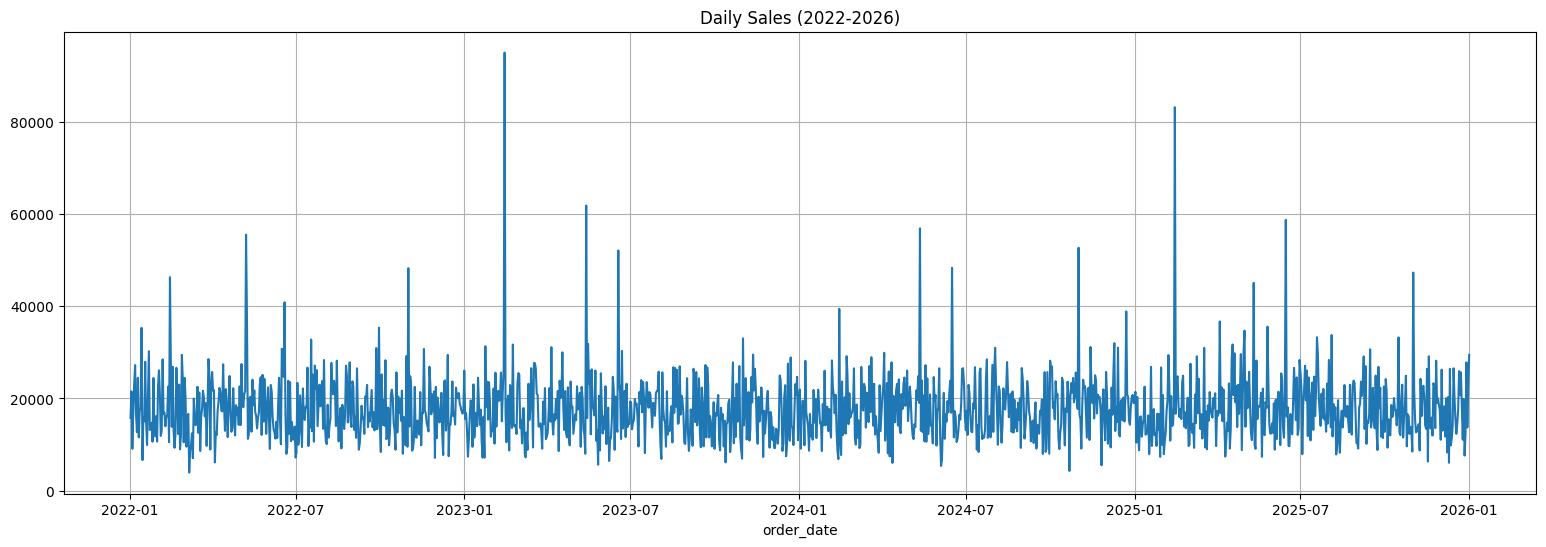

In [50]:
# daily sales from 2022 to 2026
merged.groupby(merged['order_date'].dt.date)['Price'].sum().plot(figsize=(19,6))
plt.grid()
plt.title('Daily Sales (2022-2026)')

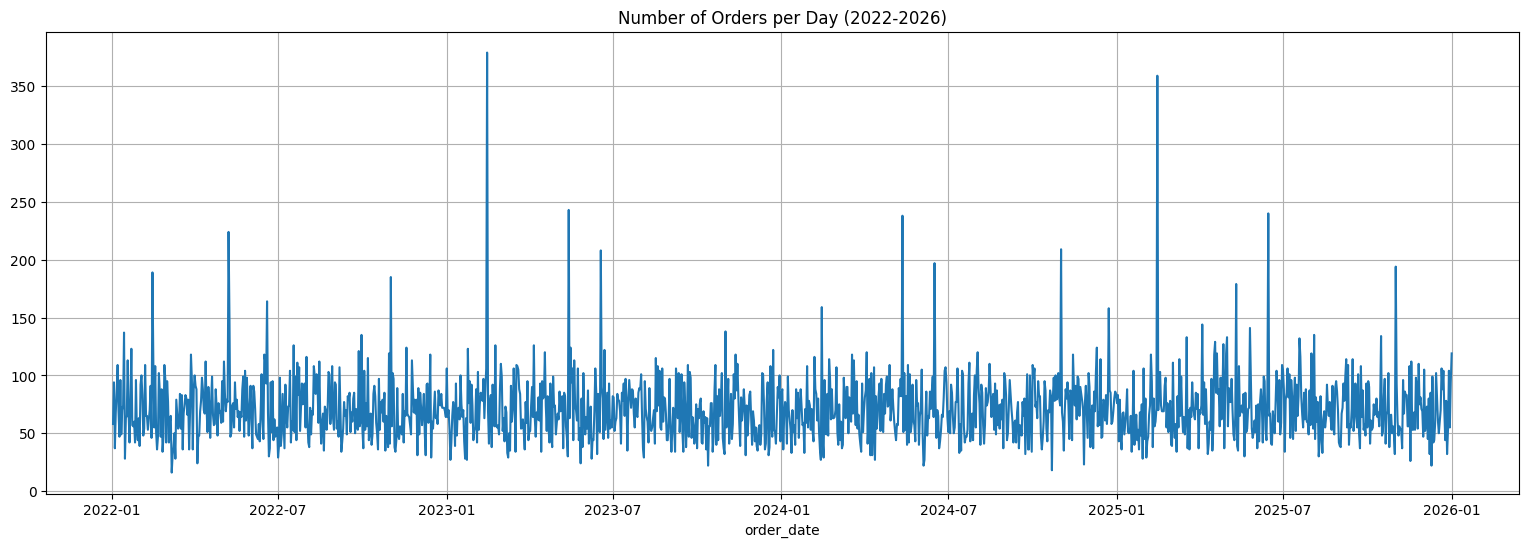

In [51]:
# number of order items daily from 2022 to 2026
merged.groupby(merged['order_date'].dt.date)['order_id'].count().plot(figsize=(19,6))
plt.grid()
plt.title('Number of Orders per Day (2022-2026)')
plt.show()

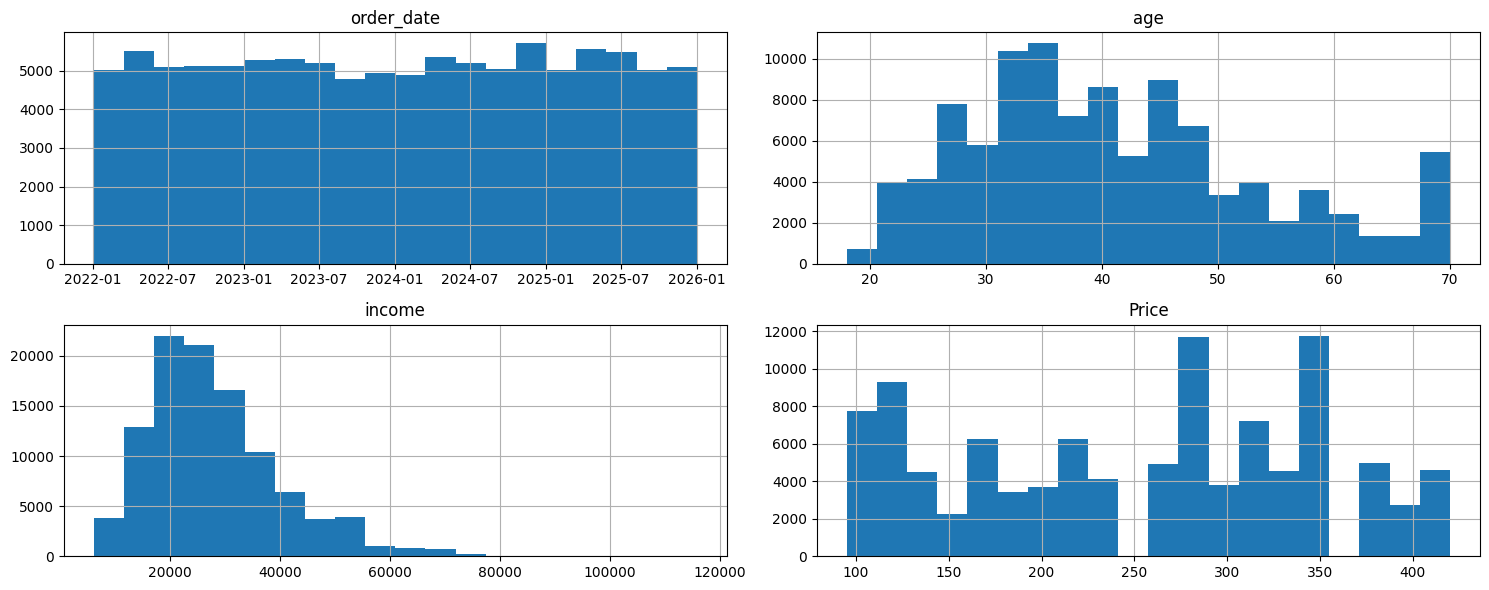

In [52]:
# distribution of the dataset
merged.hist(figsize=(15,6), bins=20)
plt.tight_layout()

In [53]:
# convert time based column to pd.to_datetime
merged['time'] = pd.to_datetime(merged['order_date']).dt.time
merged['order_date'] = pd.to_datetime(merged['order_date']).dt.date

In [54]:
merged

,order_id,order_date,customer_id,age,gender,income,payment_method,part_of_day,age_group,order,Price,order_category,time
0,ORD-000004,2025-03-10,ef15b821,63,Female,31600.0,Card,afternoon,older,Americano,100,Drinks,12:20:23
1,ORD-000004,2025-03-10,ef15b821,63,Female,31600.0,Card,afternoon,older,Chicken Inasal,310,Meal,12:20:23
2,ORD-000004,2025-03-10,ef15b821,63,Female,31600.0,Card,afternoon,older,Kare-Kare,375,Meal,12:20:23
3,ORD-00001,2022-07-25,078c3875,41,Female,12900.0,Card,afternoon,middle,Chicken Inasal,310,Meal,15:11:17
4,ORD-00003,2022-11-13,649423aa,27,Female,15700.0,Card,evening,middle,Carbonara,280,Meal,18:50:52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103846,ORD-99996,2022-07-13,16daa8f5,47,Female,44900.0,Cash,evening,older,Cafe Latte,120,Drinks,18:53:27
103847,ORD-99996,2022-07-13,16daa8f5,47,Female,44900.0,Cash,evening,older,Cake Slice,125,Dessert,18:53:27
103848,ORD-999984,2024-01-29,65daced0,33,Female,21700.0,Cash,evening,middle,Carbonara,280,Meal,18:57:51
103849,ORD-999984,2024-01-29,65daced0,33,Female,21700.0,Cash,evening,middle,Sinigang,290,Meal,18:57:51


In [55]:
merged.describe()

,age,income,Price
count,103851.000000,103851.000000,103851.000000
mean,41.040346,28243.054954,249.461122
std,12.526054,12194.828141,95.089644
min,18.000000,6200.000000,95.000000
25%,32.000000,19800.000000,160.000000
50%,39.000000,26100.000000,260.000000
75%,48.000000,34000.000000,325.000000
max,70.000000,115800.000000,420.000000


In [56]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103851 entries, 0 to 103850
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   order_id        103851 non-null  object  
 1   order_date      103851 non-null  object  
 2   customer_id     103851 non-null  object  
 3   age             103851 non-null  int64   
 4   gender          103851 non-null  object  
 5   income          103851 non-null  float64 
 6   payment_method  103851 non-null  object  
 7   part_of_day     103851 non-null  category
 8   age_group       103851 non-null  category
 9   order           103851 non-null  object  
 10  Price           103851 non-null  int64   
 11  order_category  103851 non-null  object  
 12  time            103851 non-null  object  
dtypes: category(2), float64(1), int64(2), object(8)
memory usage: 8.9+ MB
